# Bảng doanh thu theo từng tháng


Bảng doanh thu theo tháng (từ featured_table):


,month,Revenue,COGS,net_profit
0,2012-07,1.304068e+08,1.025165e+08,27890299.64
1,2012-08,1.590892e+08,1.255853e+08,33503933.88
2,2012-09,1.293071e+08,1.025962e+08,26710979.00
3,2012-10,1.101857e+08,8.805481e+07,22130889.42
4,2012-11,9.818630e+07,7.782008e+07,20366217.83
...,...,...,...,...
121,2022-08,1.135429e+08,9.403338e+07,19509565.13
122,2022-09,8.576429e+07,7.839524e+07,7369044.32
123,2022-10,7.519445e+07,6.196989e+07,13224558.51
124,2022-11,5.220008e+07,4.709802e+07,5102060.14


Bảng doanh thu theo tuần (từ featured_table):


,week,Revenue,COGS,net_profit
0,2012-07-02/2012-07-08,15958133.65,12568073.67,3390059.98
1,2012-07-09/2012-07-15,33180026.28,26002754.56,7177271.72
2,2012-07-16/2012-07-22,31317337.60,24742285.78,6575051.82
3,2012-07-23/2012-07-29,34213522.89,26865359.12,7348163.77
4,2012-07-30/2012-08-05,52619226.56,41253765.90,11365460.66
...,...,...,...,...
543,2022-11-28/2022-12-04,9788276.35,10033174.70,-244898.35
544,2022-12-05/2022-12-11,8965066.77,9223189.62,-258122.85
545,2022-12-12/2022-12-18,11777717.78,12154000.70,-376282.92
546,2022-12-19/2022-12-25,11893447.48,11940562.09,-47114.61


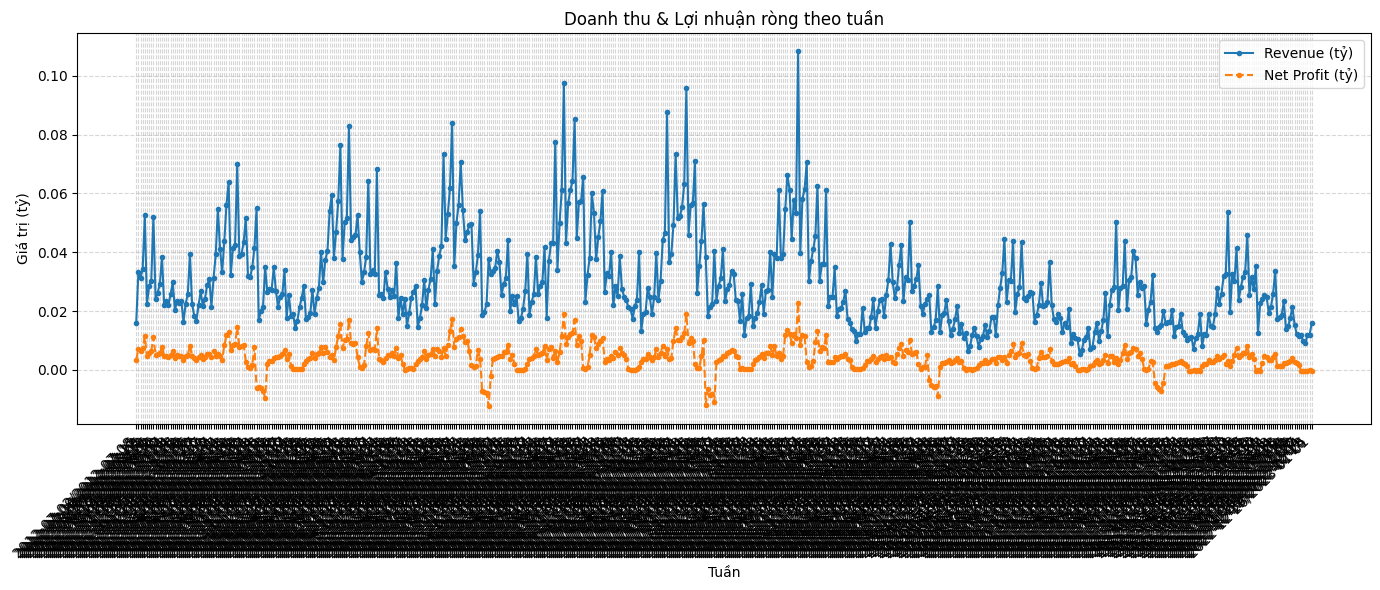

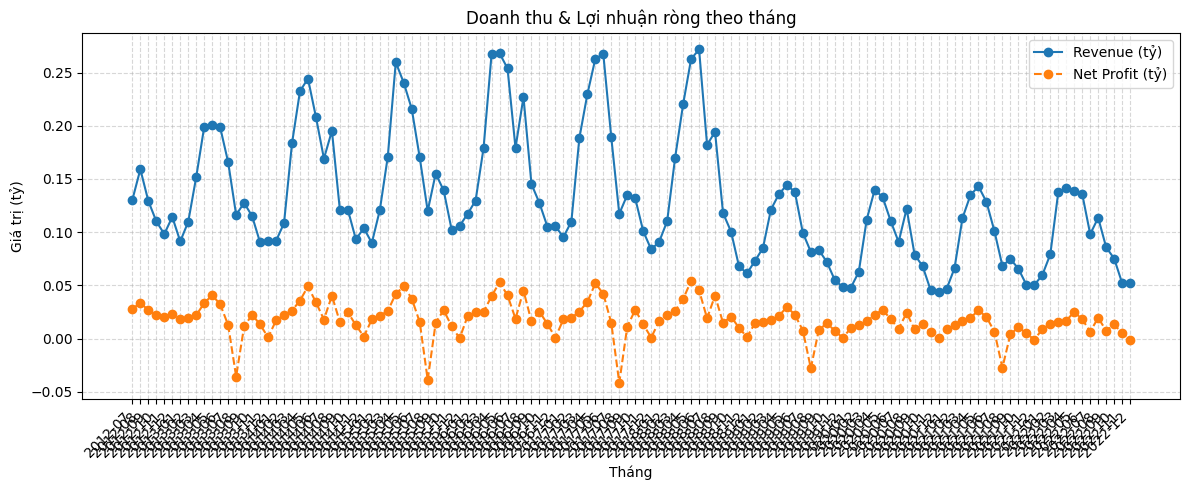

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

base_dir = Path.cwd()
output_dir = None
for _ in range(5):
    candidate = base_dir / 'data' / 'output'
    if candidate.exists():
        output_dir = candidate
        break
    base_dir = base_dir.parent

if output_dir is None:
    raise FileNotFoundError('Không tìm thấy thư mục data/output trong cây thư mục hiện tại')

featured_path = output_dir / 'featured_table.parquet'
master_path = output_dir / 'master_table.csv'

if featured_path.exists():
    df = pd.read_parquet(featured_path)
    df['month'] = df['Date'].dt.to_period('M')
    df['week'] = df['Date'].dt.to_period('W')

    # Handle COGS column naming variations in featured table
    if 'COGS' in df.columns:
        cogs_col = 'COGS'
    elif 'daily_cogs' in df.columns:
        cogs_col = 'daily_cogs'
    elif 'Daily_COGS' in df.columns:
        cogs_col = 'Daily_COGS'
    else:
        cogs_col = None

    monthly_revenue = (
        df.groupby('month', as_index=False)['Revenue']
          .sum()
          .sort_values('month')
    )
    weekly_revenue = (
        df.groupby('week', as_index=False)['Revenue']
          .sum()
          .sort_values('week')
    )

    # compute COGS and net profit if available
    if cogs_col:
        monthly_cogs = (
            df.groupby('month', as_index=False)[cogs_col]
              .sum()
              .sort_values('month')
              .rename(columns={cogs_col: 'COGS'})
        )
        weekly_cogs = (
            df.groupby('week', as_index=False)[cogs_col]
              .sum()
              .sort_values('week')
              .rename(columns={cogs_col: 'COGS'})
        )
    else:
        monthly_cogs = monthly_revenue.copy()
        monthly_cogs['COGS'] = 0
        weekly_cogs = weekly_revenue.copy()
        weekly_cogs['COGS'] = 0

    monthly_revenue = monthly_revenue.merge(monthly_cogs, on='month')
    monthly_revenue['net_profit'] = monthly_revenue['Revenue'] - monthly_revenue['COGS']
    weekly_revenue = weekly_revenue.merge(weekly_cogs, on='week')
    weekly_revenue['net_profit'] = weekly_revenue['Revenue'] - weekly_revenue['COGS']

    print('Bảng doanh thu theo tháng (từ featured_table):')
    display(monthly_revenue)
    print('Bảng doanh thu theo tuần (từ featured_table):')
    display(weekly_revenue)

elif master_path.exists():
    df = pd.read_csv(master_path, parse_dates=['order_date'])
    df['month'] = df['order_date'].dt.to_period('M')
    df['week'] = df['order_date'].dt.to_period('W')
    monthly_revenue = (
        df.groupby('month', as_index=False)['line_revenue']
          .sum()
          .sort_values('month')
          .rename(columns={'line_revenue': 'Revenue'})
    )
    weekly_revenue = (
        df.groupby('week', as_index=False)['line_revenue']
          .sum()
          .sort_values('week')
          .rename(columns={'line_revenue': 'Revenue'})
    )

    # compute COGS/net profit from master table if available
    if 'line_cogs' in df.columns:
        monthly_cogs = (
            df.groupby('month', as_index=False)['line_cogs']
              .sum()
              .sort_values('month')
              .rename(columns={'line_cogs': 'COGS'})
        )
        weekly_cogs = (
            df.groupby('week', as_index=False)['line_cogs']
              .sum()
              .sort_values('week')
              .rename(columns={'line_cogs': 'COGS'})
        )
    else:
        monthly_cogs = monthly_revenue.copy(); monthly_cogs['COGS'] = 0
        weekly_cogs = weekly_revenue.copy(); weekly_cogs['COGS'] = 0

    monthly_revenue = monthly_revenue.merge(monthly_cogs, on='month')
    monthly_revenue['net_profit'] = monthly_revenue['Revenue'] - monthly_revenue['COGS']
    weekly_revenue = weekly_revenue.merge(weekly_cogs, on='week')
    weekly_revenue['net_profit'] = weekly_revenue['Revenue'] - weekly_cogs['COGS']

    print('Bảng doanh thu theo tháng (từ master_table):')
    display(monthly_revenue)
    print('Bảng doanh thu theo tuần (từ master_table):')
    display(weekly_revenue)
else:
    raise FileNotFoundError('Không tìm thấy featured_table.parquet hoặc master_table.csv trong data/output')

# Vẽ biểu đồ doanh thu theo tuần (Revenue và Net Profit)
plt.figure(figsize=(14, 6))
plt.plot(weekly_revenue['week'].astype(str), weekly_revenue['Revenue'] / 1e9, marker='.', linestyle='-', label='Revenue (tỷ)')
plt.plot(weekly_revenue['week'].astype(str), weekly_revenue['net_profit'] / 1e9, marker='.', linestyle='--', label='Net Profit (tỷ)')
plt.xticks(rotation=45, ha='right')
plt.title('Doanh thu & Lợi nhuận ròng theo tuần')
plt.xlabel('Tuần')
plt.ylabel('Giá trị (tỷ)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='y')
plt.show()

# Vẽ biểu đồ doanh thu theo tháng (Revenue và Net Profit)
plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue['month'].astype(str), monthly_revenue['Revenue'] / 1e9, marker='o', linestyle='-', label='Revenue (tỷ)')
plt.plot(monthly_revenue['month'].astype(str), monthly_revenue['net_profit'] / 1e9, marker='o', linestyle='--', label='Net Profit (tỷ)')
plt.xticks(rotation=45, ha='right')
plt.title('Doanh thu & Lợi nhuận ròng theo tháng')
plt.xlabel('Tháng')
plt.ylabel('Giá trị (tỷ)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='y')
plt.show()


Found output directory: d:\DATATHON\data\output

=== PHÂN TÍCH THEO PROMOTION TYPE ===
promo_type  total_revenue  total_net_profit  order_count  avg_discount
percentage   4.314083e+09     -4.423393e+08       255366     15.345398
     fixed   3.717472e+08     -2.352573e+08        20950     50.000000


,promo_type,total_revenue,total_net_profit,order_count,avg_discount
1,percentage,4.314083e+09,-4.423393e+08,255366,15.345398
0,fixed,3.717472e+08,-2.352573e+08,20950,50.000000



=== PHÂN TÍCH THEO PROMOTION CHANNEL ===
promo_channel  total_revenue  total_net_profit  order_count  avg_discount
 all_channels   1.986129e+09     -2.292681e+08       127687     16.244520
       online   1.258133e+09     -3.323598e+08        66171     26.163516
        email   8.036246e+08     -4.337054e+06        41576     10.860881
 social_media   5.651188e+08     -1.052566e+08        31977     18.000000
     in_store   7.282432e+07     -6.375165e+06         8905     15.000000


,promo_channel,total_revenue,total_net_profit,order_count,avg_discount
0,all_channels,1.986129e+09,-2.292681e+08,127687,16.244520
3,online,1.258133e+09,-3.323598e+08,66171,26.163516
1,email,8.036246e+08,-4.337054e+06,41576,10.860881
4,social_media,5.651188e+08,-1.052566e+08,31977,18.000000
2,in_store,7.282432e+07,-6.375165e+06,8905,15.000000



=== PHÂN TÍCH THEO PROMOTION TYPE x CHANNEL ===
promo_type promo_channel  total_revenue  total_net_profit  order_count  avg_discount
percentage  all_channels   1.986129e+09     -2.292681e+08       127687     16.244520
percentage        online   8.863860e+08     -9.710248e+07        45221     15.120541
percentage         email   8.036246e+08     -4.337054e+06        41576     10.860881
percentage  social_media   5.651188e+08     -1.052566e+08        31977     18.000000
     fixed        online   3.717472e+08     -2.352573e+08        20950     50.000000
percentage      in_store   7.282432e+07     -6.375165e+06         8905     15.000000


,promo_type,promo_channel,total_revenue,total_net_profit,order_count,avg_discount
1,percentage,all_channels,1.986129e+09,-2.292681e+08,127687,16.244520
4,percentage,online,8.863860e+08,-9.710248e+07,45221,15.120541
2,percentage,email,8.036246e+08,-4.337054e+06,41576,10.860881
5,percentage,social_media,5.651188e+08,-1.052566e+08,31977,18.000000
0,fixed,online,3.717472e+08,-2.352573e+08,20950,50.000000
3,percentage,in_store,7.282432e+07,-6.375165e+06,8905,15.000000


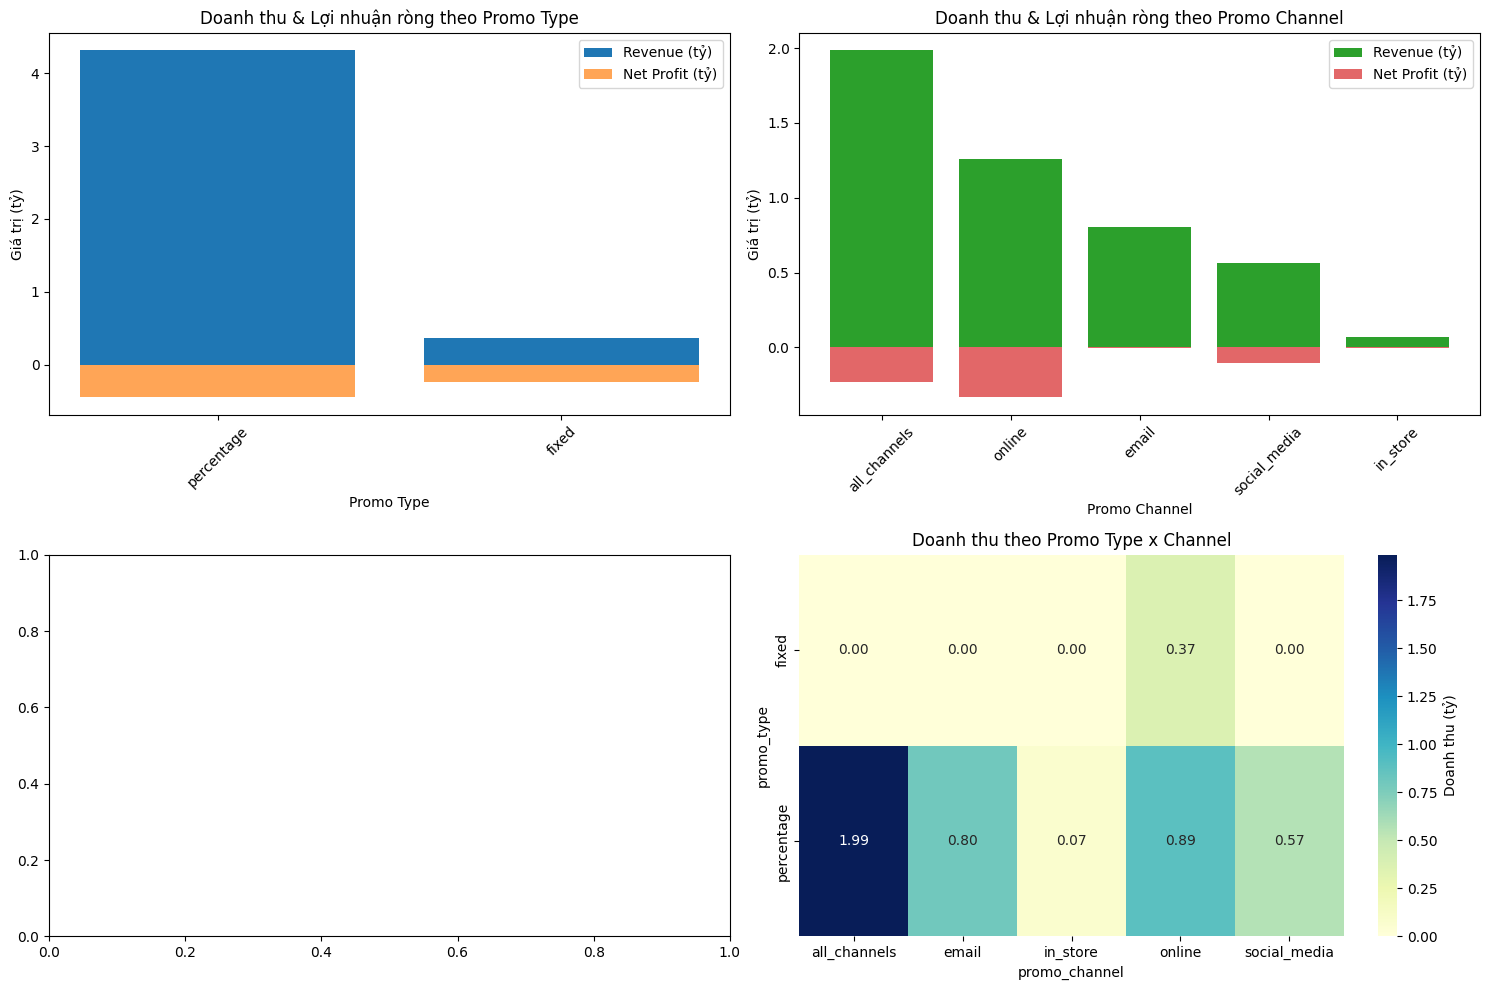

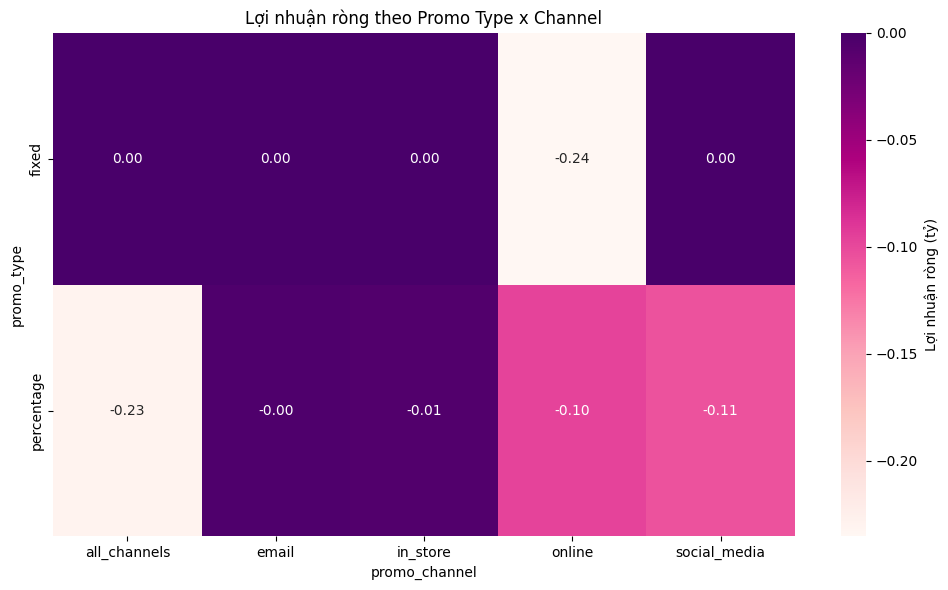


=== PHÂN TÍCH THÊM: Applied Category & Duration ===
Found promotions.csv in: d:\DATATHON\data\raw
Promotions table shape: (50, 10)
Promotions table columns: ['promo_id', 'promo_name', 'promo_type', 'discount_value', 'start_date', 'end_date', 'applicable_category', 'promo_channel', 'stackable_flag', 'min_order_value']

--- PHÂN TÍCH THEO APPLICABLE CATEGORY ---
applicable_category  total_revenue  total_net_profit  order_count  avg_discount
                NaN   4.241259e+09     -4.359642e+08       246461     15.357878
         Streetwear   3.717472e+08     -2.352573e+08        20950     50.000000
            Outdoor   7.282432e+07     -6.375165e+06         8905     15.000000


,applicable_category,total_revenue,total_net_profit,order_count,avg_discount
2,NaN,4.241259e+09,-4.359642e+08,246461,15.357878
1,Streetwear,3.717472e+08,-2.352573e+08,20950,50.000000
0,Outdoor,7.282432e+07,-6.375165e+06,8905,15.000000


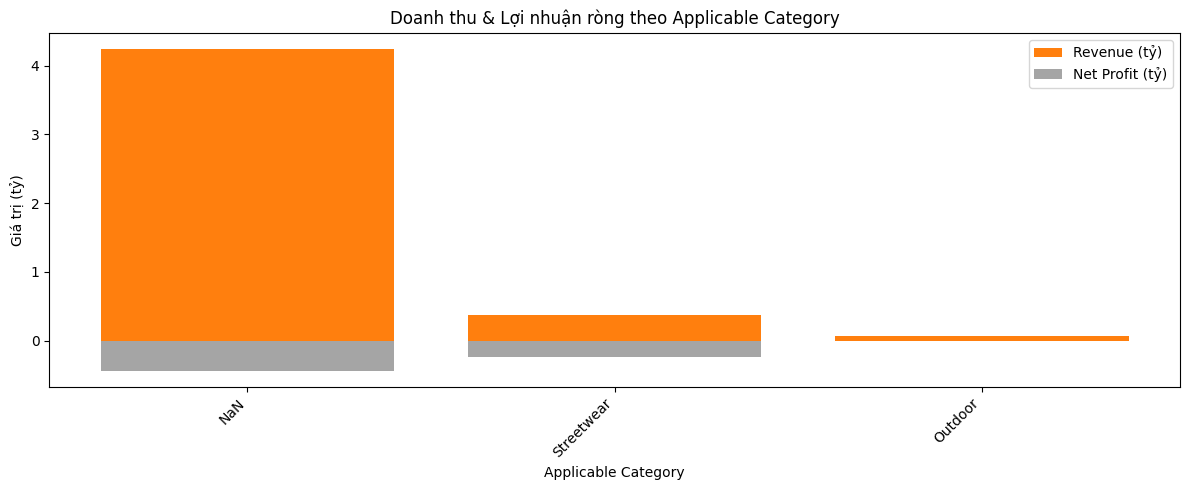


--- PHÂN TÍCH THEO PROMOTION DURATION ---
duration_bucket  total_revenue  total_net_profit  order_count  avg_discount  avg_duration
     15-30 ngày   2.501371e+09     -2.468619e+08       137913     14.691675     29.563167
     31-60 ngày   2.184459e+09     -4.307347e+08       138403     21.242459     38.974227


,duration_bucket,total_revenue,total_net_profit,order_count,avg_discount,avg_duration
0,15-30 ngày,2.501371e+09,-2.468619e+08,137913,14.691675,29.563167
1,31-60 ngày,2.184459e+09,-4.307347e+08,138403,21.242459,38.974227


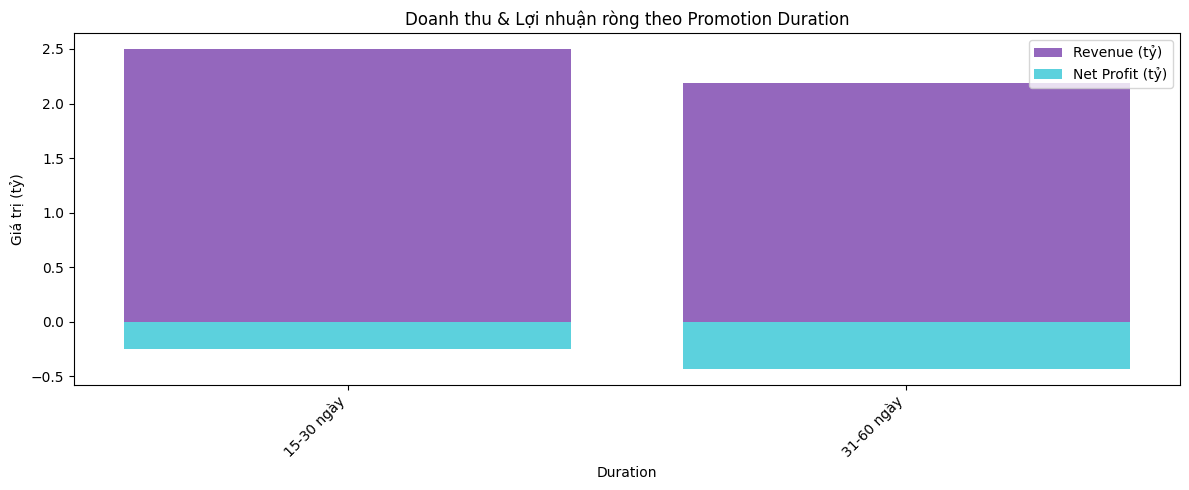

In [17]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

base_dir = Path.cwd()
output_dir = None
for _ in range(10):
    candidate = base_dir / 'data' / 'output'
    if candidate.exists():
        output_dir = candidate
        break
    base_dir = base_dir.parent

if output_dir is None:
    raise FileNotFoundError('Không tìm thấy thư mục data/output trong cây thư mục hiện tại')

print(f'Found output directory: {output_dir}')
master_path = output_dir / 'master_table.csv'

# include line_cogs to compute net profit
promo_df = pd.read_csv(master_path, usecols=['promo_id','promo_type','promo_channel','discount_value','line_revenue','line_cogs'], low_memory=False)
promo_df = promo_df[promo_df['promo_id'] != 'NO_PROMO']

# compute net profit per line
if 'line_cogs' in promo_df.columns:
    promo_df['net_profit'] = promo_df['line_revenue'].fillna(0) - promo_df['line_cogs'].fillna(0)
else:
    promo_df['net_profit'] = promo_df['line_revenue'].fillna(0)

# Phân tích theo promo_type
print('\n=== PHÂN TÍCH THEO PROMOTION TYPE ===')
promo_type_summary = (
    promo_df
    .groupby('promo_type', dropna=False, as_index=False)
    .agg(
        total_revenue=('line_revenue','sum'),
        total_net_profit=('net_profit','sum'),
        order_count=('line_revenue','size'),
        avg_discount=('discount_value','mean'),
    )
    .sort_values('total_revenue', ascending=False)
)
print(promo_type_summary.to_string(index=False))
display(promo_type_summary)

# Phân tích theo promo_channel
print('\n=== PHÂN TÍCH THEO PROMOTION CHANNEL ===')
promo_channel_summary = (
    promo_df
    .groupby('promo_channel', dropna=False, as_index=False)
    .agg(
        total_revenue=('line_revenue','sum'),
        total_net_profit=('net_profit','sum'),
        order_count=('line_revenue','size'),
        avg_discount=('discount_value','mean'),
    )
    .sort_values('total_revenue', ascending=False)
)
print(promo_channel_summary.to_string(index=False))
display(promo_channel_summary)

# Phân tích kết hợp promo_type x promo_channel
print('\n=== PHÂN TÍCH THEO PROMOTION TYPE x CHANNEL ===')
promo_combined_summary = (
    promo_df
    .groupby(['promo_type','promo_channel'], dropna=False, as_index=False)
    .agg(
        total_revenue=('line_revenue','sum'),
        total_net_profit=('net_profit','sum'),
        order_count=('line_revenue','size'),
        avg_discount=('discount_value','mean'),
    )
    .sort_values('total_revenue', ascending=False)
)
print(promo_combined_summary.to_string(index=False))
display(promo_combined_summary)

# Chart 1: Doanh thu theo promo_type
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0,0].bar(promo_type_summary['promo_type'].astype(str), promo_type_summary['total_revenue'] / 1e9, color='tab:blue', label='Revenue (tỷ)')
axes[0,0].bar(promo_type_summary['promo_type'].astype(str), promo_type_summary['total_net_profit'] / 1e9, color='tab:orange', alpha=0.7, label='Net Profit (tỷ)')
axes[0,0].set_title('Doanh thu & Lợi nhuận ròng theo Promo Type')
axes[0,0].set_xlabel('Promo Type')
axes[0,0].set_ylabel('Giá trị (tỷ)')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].legend()

# Chart 2: Doanh thu theo promo_channel
axes[0,1].bar(promo_channel_summary['promo_channel'].astype(str), promo_channel_summary['total_revenue'] / 1e9, color='tab:green', label='Revenue (tỷ)')
axes[0,1].bar(promo_channel_summary['promo_channel'].astype(str), promo_channel_summary['total_net_profit'] / 1e9, color='tab:red', alpha=0.7, label='Net Profit (tỷ)')
axes[0,1].set_title('Doanh thu & Lợi nhuận ròng theo Promo Channel')
axes[0,1].set_xlabel('Promo Channel')
axes[0,1].set_ylabel('Giá trị (tỷ)')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].legend()

# Chart 3: Heatmap doanh thu theo Type x Channel (Revenue)
pivot_table = promo_combined_summary.pivot_table(
    values='total_revenue', 
    index='promo_type', 
    columns='promo_channel', 
    aggfunc='sum',
    fill_value=0
)

import seaborn as sns
sns.heatmap(pivot_table / 1e9, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Doanh thu (tỷ)'})
plt.title('Doanh thu theo Promo Type x Channel')
plt.tight_layout()
plt.show()

# Chart 4: Heatmap Lợi nhuận ròng theo Type x Channel (Net Profit)
pivot_net = promo_combined_summary.pivot_table(
    values='total_net_profit',
    index='promo_type',
    columns='promo_channel',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot_net / 1e9, annot=True, fmt='.2f', cmap='RdPu', cbar_kws={'label': 'Lợi nhuận ròng (tỷ)'})
plt.title('Lợi nhuận ròng theo Promo Type x Channel')
plt.tight_layout()
plt.show()

# ===== PHÂN TÍCH THÊM: Applicable Category và Duration =====
print('\n=== PHÂN TÍCH THÊM: Applied Category & Duration ===')

# Đọc bảng promotions từ data/raw hoặc data/interim
raw_dir = output_dir.parent / 'raw'
interim_dir = output_dir.parent / 'interim'

promotions_path = None
if (raw_dir / 'promotions.csv').exists():
    promotions_path = raw_dir / 'promotions.csv'
    print(f'Found promotions.csv in: {raw_dir}')
elif (interim_dir / 'promotions.csv').exists():
    promotions_path = interim_dir / 'promotions.csv'
    print(f'Found promotions.csv in: {interim_dir}')

if promotions_path and promotions_path.exists():
    promo_info = pd.read_csv(promotions_path)
    print(f'Promotions table shape: {promo_info.shape}')
    print(f'Promotions table columns: {promo_info.columns.tolist()}')
    
    # Tính duration (nếu có start_date và end_date)
    if 'start_date' in promo_info.columns and 'end_date' in promo_info.columns:
        promo_info['start_date'] = pd.to_datetime(promo_info['start_date'])
        promo_info['end_date'] = pd.to_datetime(promo_info['end_date'])
        promo_info['duration_days'] = (promo_info['end_date'] - promo_info['start_date']).dt.days
    
    # Merge với promo_df để lấy doanh thu
    promo_df_merged = promo_df.merge(promo_info[['promo_id','applicable_category','duration_days']] if 'duration_days' in promo_info.columns else promo_info[['promo_id','applicable_category']], on='promo_id', how='left')
    
    # Phân tích theo applicable_category
    if 'applicable_category' in promo_info.columns:
        print('\n--- PHÂN TÍCH THEO APPLICABLE CATEGORY ---')
        category_summary = (
            promo_df_merged
            .groupby('applicable_category', dropna=False, as_index=False)
            .agg(
                total_revenue=('line_revenue','sum'),
                total_net_profit=('net_profit','sum'),
                order_count=('line_revenue','size'),
                avg_discount=('discount_value','mean'),
            )
            .sort_values('total_revenue', ascending=False)
        )
        print(category_summary.to_string(index=False))
        display(category_summary)
        
        # Chart theo category (Revenue & Net Profit)
        plt.figure(figsize=(12, 5))
        plt.bar(category_summary['applicable_category'].fillna('NaN').astype(str), category_summary['total_revenue'] / 1e9, color='tab:orange', label='Revenue (tỷ)')
        plt.bar(category_summary['applicable_category'].fillna('NaN').astype(str), category_summary['total_net_profit'] / 1e9, color='tab:gray', alpha=0.7, label='Net Profit (tỷ)')
        plt.xticks(rotation=45, ha='right')
        plt.title('Doanh thu & Lợi nhuận ròng theo Applicable Category')
        plt.xlabel('Applicable Category')
        plt.ylabel('Giá trị (tỷ)')
        plt.legend()
        plt.tight_layout()
        plt.show()
    
    # Phân tích theo duration (nếu có)
    if 'duration_days' in promo_df_merged.columns:
        print('\n--- PHÂN TÍCH THEO PROMOTION DURATION ---')
        promo_df_merged['duration_bucket'] = pd.cut(
            promo_df_merged['duration_days'],
            bins=[-1, 7, 14, 30, 60, 365, 10000],
            labels=['≤7 ngày', '8-14 ngày', '15-30 ngày', '31-60 ngày', '61-365 ngày', '>365 ngày']
        )
        
        duration_summary = (
            promo_df_merged
            .groupby('duration_bucket', as_index=False)
            .agg(
                total_revenue=('line_revenue','sum'),
                total_net_profit=('net_profit','sum'),
                order_count=('line_revenue','size'),
                avg_discount=('discount_value','mean'),
                avg_duration=('duration_days','mean'),
            )
            .sort_values('total_revenue', ascending=False)
        )
        print(duration_summary.to_string(index=False))
        display(duration_summary)
        
        # Chart theo duration (Revenue & Net Profit)
        plt.figure(figsize=(12, 5))
        plt.bar(duration_summary['duration_bucket'].astype(str), duration_summary['total_revenue'] / 1e9, color='tab:purple', label='Revenue (tỷ)')
        plt.bar(duration_summary['duration_bucket'].astype(str), duration_summary['total_net_profit'] / 1e9, color='tab:cyan', alpha=0.7, label='Net Profit (tỷ)')
        plt.xticks(rotation=45, ha='right')
        plt.title('Doanh thu & Lợi nhuận ròng theo Promotion Duration')
        plt.xlabel('Duration')
        plt.ylabel('Giá trị (tỷ)')
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print('Không tìm thấy file promotions.csv. Bỏ qua phân tích thêm.')


=== PHÂN TÍCH NHÂN KHẨU HỌC KHÁCH HÀNG ===

--- PHÂN BỐ KHÁCH HÀNG THEO GIỚI TÍNH ---
    gender  total_revenue  order_count  unique_customers  avg_order_value
    Female   7.677347e+09       350247             44196     21919.806763
      Male   7.395187e+09       336916             42481     21949.647249
Non-binary   6.083354e+08        27506              3569     22116.460175


,gender,total_revenue,order_count,unique_customers,avg_order_value
0,Female,7.677347e+09,350247,44196,21919.806763
1,Male,7.395187e+09,336916,42481,21949.647249
2,Non-binary,6.083354e+08,27506,3569,22116.460175



--- PHÂN BỐ KHÁCH HÀNG THEO NHÓM TUỔI ---
age_group  total_revenue  order_count  unique_customers  avg_order_value
    25-34   4.630011e+09       210288             26802     22017.474451
    35-44   4.126282e+09       188532             23642     21886.374057
    45-54   3.019380e+09       136959             17193     22045.866535
    18-24   2.152382e+09        98453             12599     21862.022747
      55+   1.752815e+09        80437             10010     21791.155364


,age_group,total_revenue,order_count,unique_customers,avg_order_value
1,25-34,4.630011e+09,210288,26802,22017.474451
2,35-44,4.126282e+09,188532,23642,21886.374057
3,45-54,3.019380e+09,136959,17193,22045.866535
0,18-24,2.152382e+09,98453,12599,21862.022747
4,55+,1.752815e+09,80437,10010,21791.155364



--- PHÂN TÍCH GENDER x AGE_GROUP ---
    gender age_group  total_revenue  order_count  unique_customers  avg_order_value
    Female     25-34   2.262807e+09       102979             13142     21973.483610
      Male     25-34   2.194617e+09        99441             12627     22069.535244
    Female     35-44   2.013267e+09        92132             11495     21851.988552
      Male     35-44   1.952433e+09        89188             11212     21891.209441
    Female     45-54   1.467364e+09        66594              8414     22034.477073
      Male     45-54   1.429068e+09        64818              8082     22047.397251
    Female     18-24   1.086578e+09        49495              6241     21953.293889
      Male     18-24   9.856417e+08        45345              5864     21736.502202
    Female       55+   8.473295e+08        39047              4904     21700.246736
      Male       55+   8.334276e+08        38124              4696     21860.970078
Non-binary     25-34   1.725866e+08   

,gender,age_group,total_revenue,order_count,unique_customers,avg_order_value
1,Female,25-34,2.262807e+09,102979,13142,21973.483610
6,Male,25-34,2.194617e+09,99441,12627,22069.535244
2,Female,35-44,2.013267e+09,92132,11495,21851.988552
7,Male,35-44,1.952433e+09,89188,11212,21891.209441
3,Female,45-54,1.467364e+09,66594,8414,22034.477073
8,Male,45-54,1.429068e+09,64818,8082,22047.397251
0,Female,18-24,1.086578e+09,49495,6241,21953.293889
5,Male,18-24,9.856417e+08,45345,5864,21736.502202
4,Female,55+,8.473295e+08,39047,4904,21700.246736
9,Male,55+,8.334276e+08,38124,4696,21860.970078



--- SẢN PHẨM PHỔ BIẾN THEO GIỚI TÍNH ---

Female:
  category  total_revenue  order_count
Streetwear   6.144137e+09       192459
   Outdoor   1.155280e+09       127721
    Casual   2.165434e+08        11846
      GenZ   1.613869e+08        18221

Male:
  category  total_revenue  order_count
Streetwear   5.924889e+09       185742
   Outdoor   1.108935e+09       122451
    Casual   2.064655e+08        11205
      GenZ   1.548987e+08        17518

Non-binary:
  category  total_revenue  order_count
Streetwear   489451955.98        15332
   Outdoor    89182549.58         9814
    Casual    17276282.52          940
      GenZ    12424565.50         1420

--- SẢN PHẨM PHỔ BIẾN THEO NHÓM TUỔI ---

18-24:
  category  total_revenue  order_count
Streetwear   1.719771e+09        54033
   Outdoor   3.281593e+08        36157
    Casual   5.874538e+07         3198
      GenZ   4.570644e+07         5065

25-34:
  category  total_revenue  order_count
Streetwear   3.721038e+09       116354
   Outdoor   

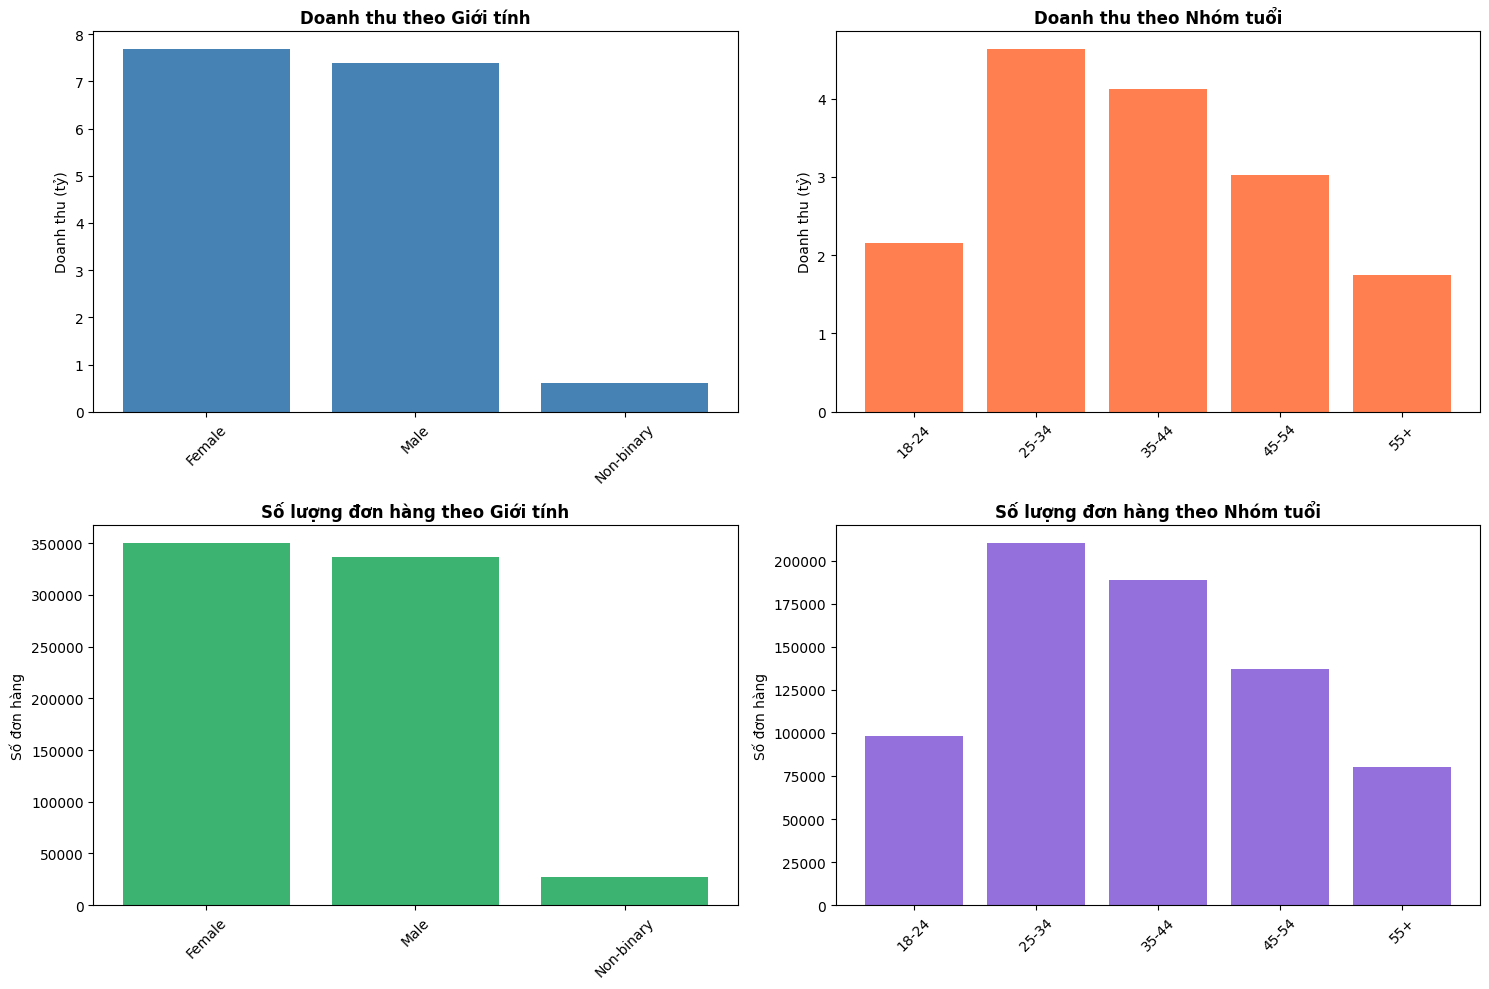


--- HEATMAP DOANH THU: GENDER x AGE_GROUP ---


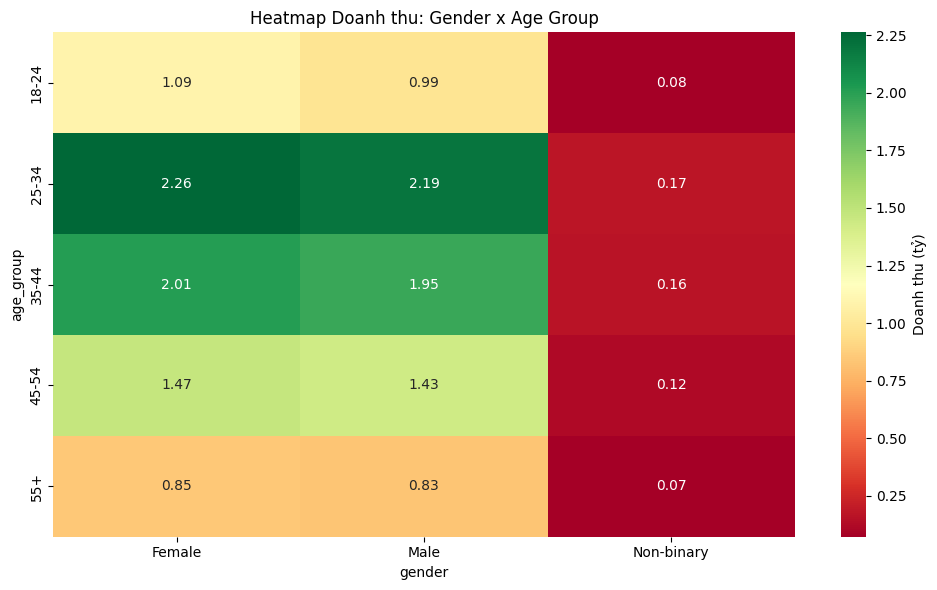


--- HEATMAP SỐ LƯỢNG ĐƠN HÀNG: GENDER x AGE_GROUP ---


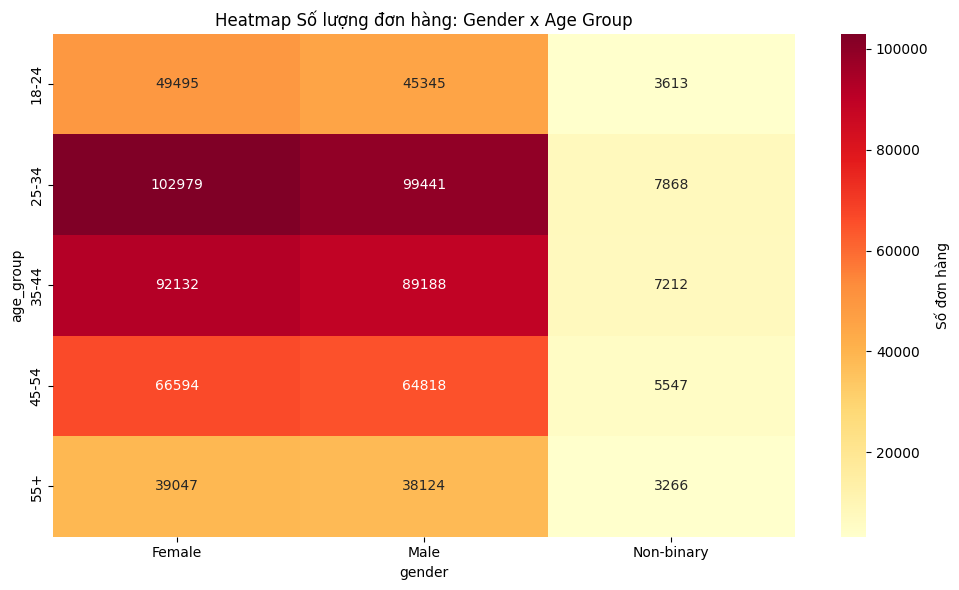

In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

base_dir = Path.cwd()
output_dir = None
for _ in range(10):
    candidate = base_dir / 'data' / 'output'
    if candidate.exists():
        output_dir = candidate
        break
    base_dir = base_dir.parent

if output_dir is None:
    raise FileNotFoundError('Không tìm thấy thư mục data/output trong cây thư mục hiện tại')

master_path = output_dir / 'master_table.csv'
master_df = pd.read_csv(master_path, low_memory=False)

print('=== PHÂN TÍCH NHÂN KHẨU HỌC KHÁCH HÀNG ===\n')

# ensure cogs column exists or create zero fallback
if 'line_cogs' not in master_df.columns:
    master_df['line_cogs'] = 0

# compute net profit per line
master_df['net_profit'] = master_df['line_revenue'].fillna(0) - master_df['line_cogs'].fillna(0)

# 1. Phân bố theo giới tính
print('--- PHÂN BỐ KHÁCH HÀNG THEO GIỚI TÍNH ---')
gender_summary = (
    master_df
    .groupby('gender', as_index=False)
    .agg(
        total_revenue=('line_revenue','sum'),
        total_cogs=('line_cogs','sum'),
        total_net_profit=('net_profit','sum'),
        order_count=('order_id','count'),
        unique_customers=('customer_id','nunique'),
        avg_order_value=('line_revenue','mean'),
    )
    .sort_values('total_revenue', ascending=False)
)
print(gender_summary.to_string(index=False))
display(gender_summary)

# 2. Phân bố theo nhóm tuổi
print('\n--- PHÂN BỐ KHÁCH HÀNG THEO NHÓM TUỔI ---')
age_summary = (
    master_df
    .groupby('age_group', as_index=False)
    .agg(
        total_revenue=('line_revenue','sum'),
        total_cogs=('line_cogs','sum'),
        total_net_profit=('net_profit','sum'),
        order_count=('order_id','count'),
        unique_customers=('customer_id','nunique'),
        avg_order_value=('line_revenue','mean'),
    )
    .sort_values('total_revenue', ascending=False)
)
print(age_summary.to_string(index=False))
display(age_summary)

# 3. Phân tích kết hợp Gender x Age_group
print('\n--- PHÂN TÍCH GENDER x AGE_GROUP ---')
gender_age_summary = (
    master_df
    .groupby(['gender','age_group'], as_index=False)
    .agg(
        total_revenue=('line_revenue','sum'),
        total_cogs=('line_cogs','sum'),
        total_net_profit=('net_profit','sum'),
        order_count=('order_id','count'),
        unique_customers=('customer_id','nunique'),
        avg_order_value=('line_revenue','mean'),
    )
    .sort_values('total_revenue', ascending=False)
)
print(gender_age_summary.to_string(index=False))
display(gender_age_summary)

# 4. Sản phẩm phổ biến theo giới tính
print('\n--- SẢN PHẨM PHỔ BIẾN THEO GIỚI TÍNH ---')
for gender in master_df['gender'].unique():
    if pd.notna(gender):
        print(f'\n{gender}:')
        gender_category = (
            master_df[master_df['gender'] == gender]
            .groupby('category', as_index=False)
            .agg(
                total_revenue=('line_revenue','sum'),
                total_cogs=('line_cogs','sum'),
                total_net_profit=('net_profit','sum'),
                order_count=('order_id','count'),
            )
            .sort_values('total_revenue', ascending=False)
            .head(5)
        )
        print(gender_category.to_string(index=False))

# 5. Sản phẩm phổ biến theo nhóm tuổi
print('\n--- SẢN PHẨM PHỔ BIẾN THEO NHÓM TUỔI ---')
for age in sorted(master_df['age_group'].dropna().unique()):
    print(f'\n{age}:')
    age_category = (
        master_df[master_df['age_group'] == age]
        .groupby('category', as_index=False)
        .agg(
            total_revenue=('line_revenue','sum'),
            total_cogs=('line_cogs','sum'),
            total_net_profit=('net_profit','sum'),
            order_count=('order_id','count'),
        )
        .sort_values('total_revenue', ascending=False)
        .head(5)
    )
    print(age_category.to_string(index=False))

# === BIỂU ĐỒ ===
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Chart 1: Doanh thu theo giới tính
axes[0, 0].bar(gender_summary['gender'], gender_summary['total_revenue'] / 1e9, color='steelblue', label='Revenue (tỷ)')
axes[0, 0].bar(gender_summary['gender'], gender_summary['total_net_profit'] / 1e9, color='gold', alpha=0.7, label='Net Profit (tỷ)')
axes[0, 0].set_title('Doanh thu & Lợi nhuận ròng theo Giới tính', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Giá trị (tỷ)')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].legend()

# Chart 2: Doanh thu theo nhóm tuổi
age_order = ['18-24', '25-34', '35-44', '45-54', '55+']
age_summary_sorted = age_summary.set_index('age_group').reindex(age_order).reset_index()
axes[0, 1].bar(age_summary_sorted['age_group'], age_summary_sorted['total_revenue'] / 1e9, color='coral', label='Revenue (tỷ)')
axes[0, 1].bar(age_summary_sorted['age_group'], age_summary_sorted['total_net_profit'] / 1e9, color='purple', alpha=0.7, label='Net Profit (tỷ)')
axes[0, 1].set_title('Doanh thu & Lợi nhuận ròng theo Nhóm tuổi', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Giá trị (tỷ)')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].legend()

# Chart 3: Số lượng đơn hàng theo gender
axes[1, 0].bar(gender_summary['gender'], gender_summary['order_count'], color='mediumseagreen')
axes[1, 0].set_title('Số lượng đơn hàng theo Giới tính', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Số đơn hàng')
axes[1, 0].tick_params(axis='x', rotation=45)

# Chart 4: Số lượng đơn hàng theo age_group
axes[1, 1].bar(age_summary_sorted['age_group'], age_summary_sorted['order_count'], color='mediumpurple')
axes[1, 1].set_title('Số lượng đơn hàng theo Nhóm tuổi', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Số đơn hàng')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Heatmap: Doanh thu Gender x Age_group
print('\n--- HEATMAP DOANH THU: GENDER x AGE_GROUP ---')
pivot_gender_age = gender_age_summary.pivot_table(
    values='total_revenue',
    index='age_group',
    columns='gender',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_gender_age / 1e9, annot=True, fmt='.2f', cmap='RdYlGn', cbar_kws={'label': 'Doanh thu (tỷ)'})
plt.title('Heatmap Doanh thu: Gender x Age Group')
plt.tight_layout()
plt.show()

# Heatmap: Lợi nhuận ròng Gender x Age_group
print('\n--- HEATMAP LỢI NHUẬN RÒNG: GENDER x AGE_GROUP ---')
pivot_net = gender_age_summary.pivot_table(
    values='total_net_profit',
    index='age_group',
    columns='gender',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_net / 1e9, annot=True, fmt='.2f', cmap='PiYG', cbar_kws={'label': 'Lợi nhuận ròng (tỷ)'})
plt.title('Heatmap Lợi nhuận ròng: Gender x Age Group')
plt.tight_layout()
plt.show()

# Heatmap: Số lượng đơn hàng Gender x Age_group
print('\n--- HEATMAP SỐ LƯỢNG ĐƠN HÀNG: GENDER x AGE_GROUP ---')
pivot_count = gender_age_summary.pivot_table(
    values='order_count',
    index='age_group',
    columns='gender',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_count, annot=True, fmt='g', cmap='YlOrRd', cbar_kws={'label': 'Số đơn hàng'})
plt.title('Heatmap Số lượng đơn hàng: Gender x Age Group')
plt.tight_layout()
plt.show()


Bảng doanh thu theo tháng (từ sales.csv):


,month,Revenue,COGS,net_profit
0,2012-07,1.304068e+08,1.025165e+08,27890299.64
1,2012-08,1.590892e+08,1.255853e+08,33503933.88
2,2012-09,1.293071e+08,1.025962e+08,26710979.00
3,2012-10,1.101857e+08,8.805481e+07,22130889.42
4,2012-11,9.818630e+07,7.782008e+07,20366217.83
...,...,...,...,...
121,2022-08,1.135429e+08,9.403338e+07,19509565.13
122,2022-09,8.576429e+07,7.839524e+07,7369044.32
123,2022-10,7.519445e+07,6.196989e+07,13224558.51
124,2022-11,5.220008e+07,4.709802e+07,5102060.14


Bảng doanh thu theo tuần (từ sales.csv):


,week,Revenue,COGS,net_profit
0,2012-07-02/2012-07-08,15958133.65,12568073.67,3390059.98
1,2012-07-09/2012-07-15,33180026.28,26002754.56,7177271.72
2,2012-07-16/2012-07-22,31317337.60,24742285.78,6575051.82
3,2012-07-23/2012-07-29,34213522.89,26865359.12,7348163.77
4,2012-07-30/2012-08-05,52619226.56,41253765.90,11365460.66
...,...,...,...,...
543,2022-11-28/2022-12-04,9788276.35,10033174.70,-244898.35
544,2022-12-05/2022-12-11,8965066.77,9223189.62,-258122.85
545,2022-12-12/2022-12-18,11777717.78,12154000.70,-376282.92
546,2022-12-19/2022-12-25,11893447.48,11940562.09,-47114.61


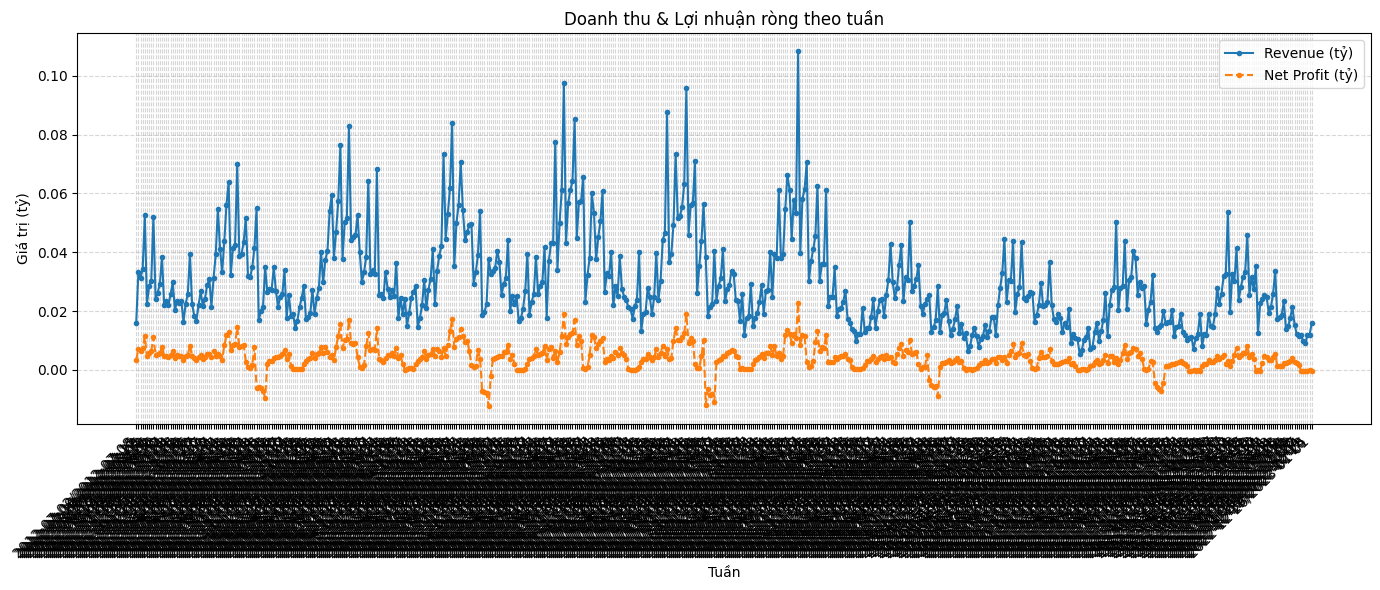

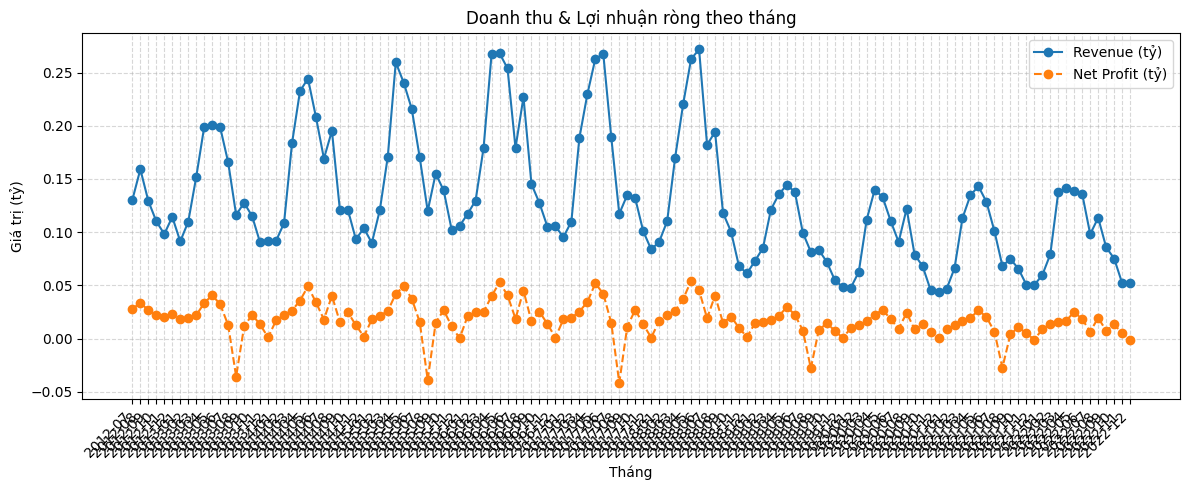

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Tìm file sales.csv trong cấu trúc thư mục
base_dir = Path.cwd()
sales_path = None

for _ in range(5):
    # Thử tìm file sales.csv ở một số vị trí phổ biến
    candidates = [
        base_dir / 'data' / 'raw' / 'sales.csv',
        base_dir / 'data' / 'sales.csv',
        base_dir / 'sales.csv'
    ]
    for candidate in candidates:
        if candidate.exists():
            sales_path = candidate
            break
            
    if sales_path is not None:
        break
    base_dir = base_dir.parent

if sales_path is None:
    raise FileNotFoundError('Không tìm thấy file sales.csv trong cây thư mục hiện tại')

# 1. Đọc dữ liệu từ sales.csv
df = pd.read_csv(sales_path, parse_dates=['Date'])

# 2. Tạo các cột thời gian (tháng, tuần)
df['month'] = df['Date'].dt.to_period('M')
df['week'] = df['Date'].dt.to_period('W')

# 3. Tính tổng doanh thu và giá vốn theo Tháng
monthly_data = (
    df.groupby('month', as_index=False)[['Revenue', 'COGS']]
      .sum()
      .sort_values('month')
)
monthly_data['net_profit'] = monthly_data['Revenue'] - monthly_data['COGS']

# 4. Tính tổng doanh thu và giá vốn theo Tuần
weekly_data = (
    df.groupby('week', as_index=False)[['Revenue', 'COGS']]
      .sum()
      .sort_values('week')
)
weekly_data['net_profit'] = weekly_data['Revenue'] - weekly_data['COGS']

# In kết quả dạng bảng
print('Bảng doanh thu theo tháng (từ sales.csv):')
display(monthly_data)
print('Bảng doanh thu theo tuần (từ sales.csv):')
display(weekly_data)

# 5. Vẽ biểu đồ doanh thu theo tuần (Revenue và Net Profit)
plt.figure(figsize=(14, 6))
plt.plot(weekly_data['week'].astype(str), weekly_data['Revenue'] / 1e9, marker='.', linestyle='-', label='Revenue (tỷ)')
plt.plot(weekly_data['week'].astype(str), weekly_data['net_profit'] / 1e9, marker='.', linestyle='--', label='Net Profit (tỷ)')
plt.xticks(rotation=45, ha='right')
plt.title('Doanh thu & Lợi nhuận ròng theo tuần')
plt.xlabel('Tuần')
plt.ylabel('Giá trị (tỷ)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='y')
plt.show()

# 6. Vẽ biểu đồ doanh thu theo tháng (Revenue và Net Profit)
plt.figure(figsize=(12, 5))
plt.plot(monthly_data['month'].astype(str), monthly_data['Revenue'] / 1e9, marker='o', linestyle='-', label='Revenue (tỷ)')
plt.plot(monthly_data['month'].astype(str), monthly_data['net_profit'] / 1e9, marker='o', linestyle='--', label='Net Profit (tỷ)')
plt.xticks(rotation=45, ha='right')
plt.title('Doanh thu & Lợi nhuận ròng theo tháng')
plt.xlabel('Tháng')
plt.ylabel('Giá trị (tỷ)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='y')
plt.show()